# Urban Sizing Ai

### Prerequisites

In [21]:
!pip install -q segmentation-models-pytorch

import os
import torch
import numpy as np
import matplotlib as plt
from PIL import Image
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is: {DEVICE}")


Device is: cuda


In [22]:
def build_resnet50_unet():
    model = smp.Unet(
        encoder_name="resnet50",       
        encoder_weights="imagenet",     
        in_channels=3,                  
        classes=1,                      
        activation='sigmoid' 
    )
    return model

model = build_resnet50_unet().to(DEVICE)

In [23]:
import os

DATA_DIR = '/kaggle/input/datasets/balraj98/massachusetts-buildings-dataset/tiff/'

x_train_dir = os.path.join(DATA_DIR, 'train')
y_train_dir = os.path.join(DATA_DIR, 'train_labels')

x_valid_dir = os.path.join(DATA_DIR, 'val')
y_valid_dir = os.path.join(DATA_DIR, 'val_labels')

x_test_dir = os.path.join(DATA_DIR, 'test')
y_test_dir = os.path.join(DATA_DIR, 'test_labels')

print(f"The paths have been set: {x_train_dir}")

The paths have been set: /kaggle/input/datasets/balraj98/massachusetts-buildings-dataset/tiff/train


In [24]:
import pandas as pd

CSV_PATH = '/kaggle/input/datasets/balraj98/massachusetts-buildings-dataset/label_class_dict.csv'

class_dict = pd.read_csv(CSV_PATH)

class_names = class_dict['name'].tolist()

class_rgb_values = class_dict[['r', 'g', 'b']].values.tolist()

print('All dataset classes and their corresponding RGB values in labels:')
print('Class Names: ', class_names)
print('Class RGB values: ', class_rgb_values)

All dataset classes and their corresponding RGB values in labels:
Class Names:  ['background', 'building']
Class RGB values:  [[0, 0, 0], [255, 255, 255]]


[ WARN:0@1197.840] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1197.840] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1197.840] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@1197.840] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@1197.841] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8199999].


Found  137 images and 137 masks
 Image tensor shape: torch.Size([3, 512, 512])
 Mask tensor shape: torch.Size([1, 512, 512])


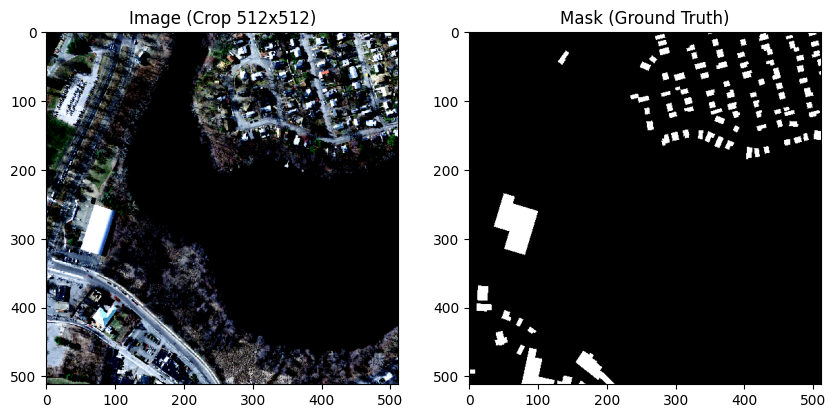

In [25]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import albumentations as A

# Transforming for training the model with different augmentations of the same images
train_transform = A.Compose([
    A.RandomCrop(width=512, height=512), # Random crop for getting a small portion of an image
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std = (0.229, 0.224, 0.225))
])

class BuildingDataset(Dataset):
    def __init__(self, images_filenames, masks_filenames, transform=None):
        self.images_filenames = images_filenames
        self.masks_filenames = masks_filenames
        self.transform = transform

    def __len__(self):
        return len(self.images_filenames)

    def __getitem__(self, idx):
        # Reading the image
        image = cv2.imread(self.images_filenames[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Reading the mask (grayscale)
        mask = cv2.imread(self.masks_filenames[idx], cv2.IMREAD_GRAYSCALE)

        mask = (mask > 127).astype(np.float32)

        # Apply the transformations
        if self.transform:
            sample = self.transform(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        # Convert to Tensors [Channels, Height, Width]
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).float().unsqueeze(0)

        return image, mask

import glob

TRAIN_IMG_PATH = '/kaggle/input/datasets/balraj98/massachusetts-buildings-dataset/tiff/train/*.tif*'
TRAIN_MASK_PATH = '/kaggle/input/datasets/balraj98/massachusetts-buildings-dataset/tiff/train_labels/*.tif*'

train_images_list = sorted(glob.glob(TRAIN_IMG_PATH))
train_masks_list = sorted(glob.glob(TRAIN_MASK_PATH))

# Verify the key
print(f"Found  {len(train_images_list)} images and {len(train_masks_list)} masks")

if len(train_images_list) == 0:
    print("No images found")
else:
    # Create the Dataset
    train_dataset = BuildingDataset(train_images_list[:600], train_masks_list[:600], transform=train_transform)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)

    # Visual test
    test_img, test_mask = train_dataset[0]
    print(f" Image tensor shape: {test_img.shape}")
    print(f" Mask tensor shape: {test_mask.shape}")

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(test_img.permute(1, 2, 0).numpy() * 0.5 + 0.5) 
    plt.title("Image (Crop 512x512)")
    plt.subplot(1, 2, 2)
    plt.imshow(test_mask.squeeze().numpy(), cmap='gray')
    plt.title("Mask (Ground Truth)")
    plt.show()

In [26]:
import torch.nn as nn
import time

# Config Loss and Optimizer
criterion_dice = smp.losses.DiceLoss(mode='binary')
criterion_bce = nn.BCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training params
EPOCHS = 15
best_iou = 0

print("Starting training")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    epoch_iou = 0
    start_time = time.time()

    for imgs, msks in train_loader:
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)

        # Reset gradients
        optimizer.zero_grad()

        preds = model(imgs)

        # Calculate combined loss
        loss_dice = criterion_dice(preds, msks)
        loss_bce = criterion_bce(preds, msks)
        loss = 0.5 * loss_dice + 0.5 * loss_bce

        # Backwards pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        #Calculate IoU
        with torch.no_grad():
            bin_preds = (preds > 0.5).float()
            intersection = (bin_preds * msks).sum()
            union = bin_preds.sum() + msks.sum() - intersection
            epoch_iou += (intersection / (union + 1e-7)).item()

    avg_loss = epoch_loss / len(train_loader)
    avg_iou = epoch_iou / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f} | mIoU: {avg_iou:.4f} | Time: {elapsed_time:.1f}s")

    if avg_iou > best_iou:
        best_iou = avg_iou
        torch.save(model.state_dict(), "best_building_model.pth")
        print(f"Saved model with mIoU: {best_iou:.4f}")

    print("Done")
            

Starting training


[ WARN:0@1198.224] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1198.224] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1198.224] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@1198.224] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@1198.224] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@1198.245] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1198.245] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1198.245] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87

Epoch [1/15] | Loss: 0.6249 | mIoU: 0.1717 | Time: 13.1s
Saved model with mIoU: 0.1717
Done


[ WARN:0@1211.656] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1211.656] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1211.656] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@1211.656] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@1211.656] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@1211.677] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1211.677] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1211.677] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87

Epoch [2/15] | Loss: 0.5818 | mIoU: 0.3144 | Time: 13.5s
Saved model with mIoU: 0.3144
Done


...

Epoch [13/15] | Loss: 0.4868 | mIoU: 0.5018 | Time: 12.9s
Done


[ WARN:0@1369.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1369.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1369.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@1369.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@1369.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@1369.974] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1369.974] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1369.974] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87

Epoch [14/15] | Loss: 0.4859 | mIoU: 0.4924 | Time: 13.0s
Done


[ WARN:0@1382.942] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1382.943] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1382.943] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@1382.943] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@1382.943] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@1382.962] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1382.962] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1382.962] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87

Epoch [15/15] | Loss: 0.4896 | mIoU: 0.4779 | Time: 13.0s
Done


[ WARN:0@1727.810] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1727.810] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1727.810] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@1727.810] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@1727.810] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6805664].


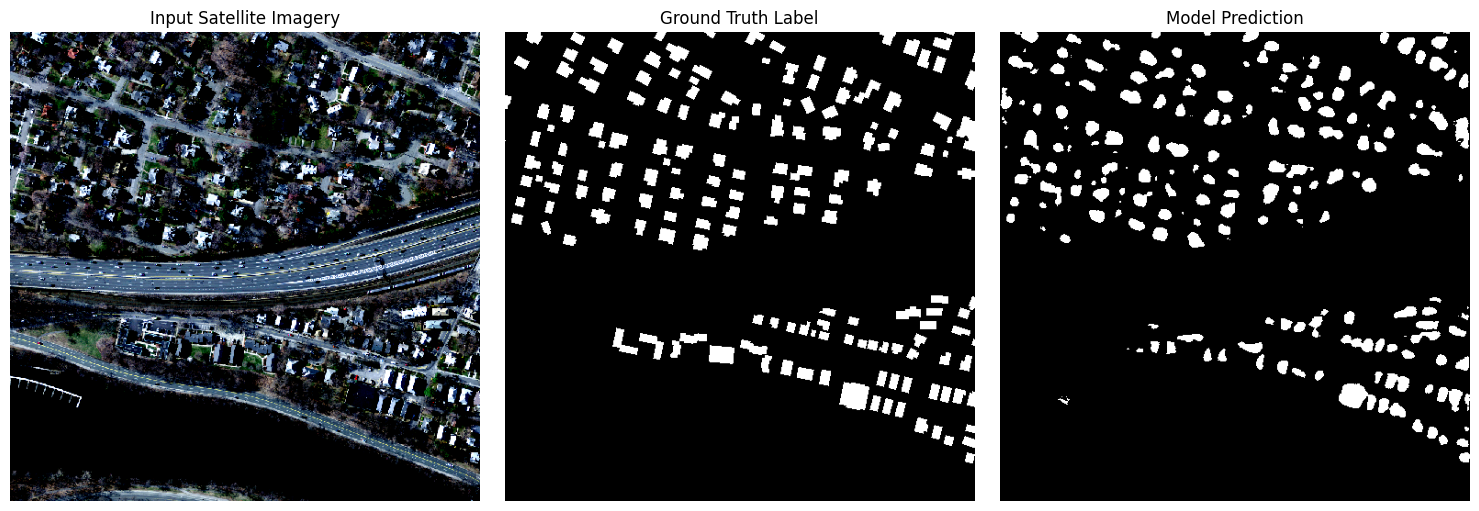

In [30]:
import matplotlib.pyplot as plt
import random
import torch

# Load the model
model.load_state_dict(torch.load("best_building_model.pth"))
model.eval()


# Select a random sample from the dataset to visualize model performance
idx = random.randint(0, len(train_dataset) - 1)
img, true_mask = train_dataset[idx]

# Perform forward pass without computing gradients
with torch.no_grad():
    # Expand tensor dimensions to simulate a batch required by the model
    img_tensor = img.unsqueeze(0).to(DEVICE)
    
    pred = model(img_tensor)
    
    pred_mask = (pred > 0.5).float().cpu().squeeze().numpy()

plt.figure(figsize=(15, 5))

# Plot the input satellite imagery
plt.subplot(1, 3, 1)
plt.title("Input Satellite Imagery")
plt.imshow(img.permute(1, 2, 0).numpy() * 0.5 + 0.5)
plt.axis('off')

# Plot the actual label provided in the dataset
plt.subplot(1, 3, 2)
plt.title("Ground Truth Label")
plt.imshow(true_mask.squeeze().numpy(), cmap='gray')
plt.axis('off')

# Plot the predicted spatial footprint generated by the AI
plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(pred_mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [31]:
import numpy as np

# Calculate dimensions from the predicted mask (512x512)
total_area_pixels = pred_mask.size
building_area_pixels = np.sum(pred_mask)

# Ratio of building footprint area to total lot area
bcr = building_area_pixels / total_area_pixels

# Calculate far
estimated_average_floors = 2
far = bcr * estimated_average_floors

print("--- Urban Morphology Metrics ---")
print(f"Total Analyzed Area: {total_area_pixels} pixels")
print(f"Detected Building Footprint: {building_area_pixels} pixels")
print(f"Building Coverage Ratio (BCR): {bcr:.2%} (Footprint density)")
print(f"Estimated Floor Area Ratio (FAR): {far:.2f} (Assuming {estimated_average_floors} floors/building)")

--- Urban Morphology Metrics ---
Total Analyzed Area: 262144 pixels
Detected Building Footprint: 22840.0 pixels
Building Coverage Ratio (BCR): 8.71% (Footprint density)
Estimated Floor Area Ratio (FAR): 0.17 (Assuming 2 floors/building)
